In [86]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784",version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [87]:
mnist["data"]

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [88]:
mnist["target"]

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [89]:
mnist["data"].shape

(70000, 784)

In [90]:
mnist["target"].shape

(70000,)

In [91]:
import numpy as np 
from matplotlib import pyplot as plt
import pandas as pd

In [92]:
data = mnist["data"]
target = mnist["target"]

In [93]:
data_target_merged = pd.concat([data,target], axis=1)
data_target_merged

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


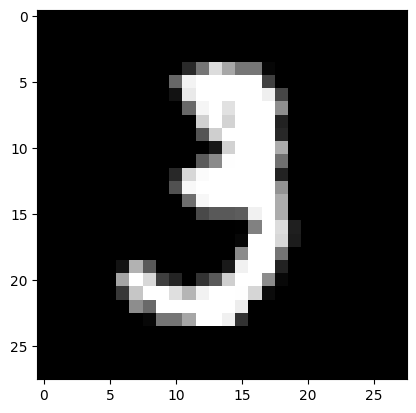

In [94]:
first_img = data.iloc[10,:].values
img = first_img.reshape(28,28)
plt.imshow(img, cmap="gray")

In [95]:
import torch
import torchvision.transforms as transforms
from torchvision.utils import save_image
from matplotlib import pyplot as plt
import cv2 as cv

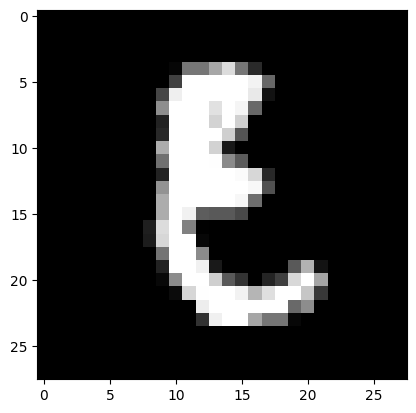

In [96]:
Horizontal_Flipping_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5) 
])
img = img.astype("uint8")
flipped_img = Horizontal_Flipping_Transformation(img)
plt.imshow(np.array(flipped_img), cmap="gray")

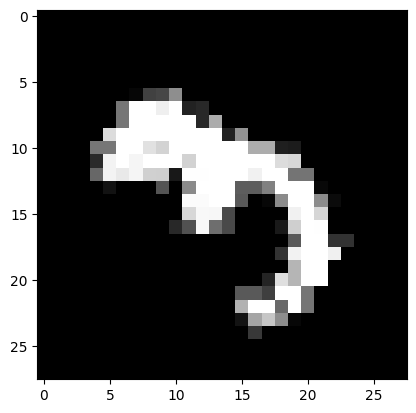

In [97]:
Rotate_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=66)
])

rotated_img = Rotate_Transformation(img)
plt.imshow(rotated_img,cmap="gray")

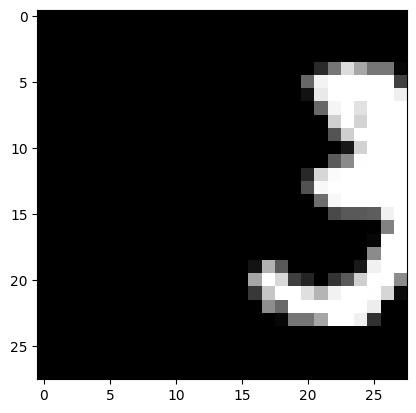

In [98]:
from scipy.ndimage import shift

shifted_img = shift(img, shift=[0, 10]) 
plt.imshow(shifted_img, cmap="gray")

In [99]:
import random
import pandas as pd 

def rand_rot_img_df(dataset,max_degree,min_degree,amount_of_rots):
    new_rows = []
    for i in range(dataset.shape[0]):
        img_cols = dataset.iloc[i,:].values
        img_label = dataset.iloc[i,-1]
        img = img_cols[:-1].reshape(28,28)
        img = img.astype("uint8")
        for c in range(amount_of_rots):
            random_i = random.randint(int(min_degree), int(max_degree))
            Rotate_Transformation = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomRotation(degrees=random_i)
                ])
            rotated_img = Rotate_Transformation(img)  
            img_flat = np.array(rotated_img).flatten()
            img_flat_with_label = np.append(img_flat, img_label)
            new_rows.append(pd.Series(img_flat_with_label, index=dataset.columns))
    augmented_df = pd.DataFrame(new_rows)
    return augmented_df

In [100]:
rotated_imgs = rand_rot_img_df(data_target_merged, 10, 5, 2)
rotated_imgs.shape

(140000, 785)

In [101]:
rotated_imgs.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


3


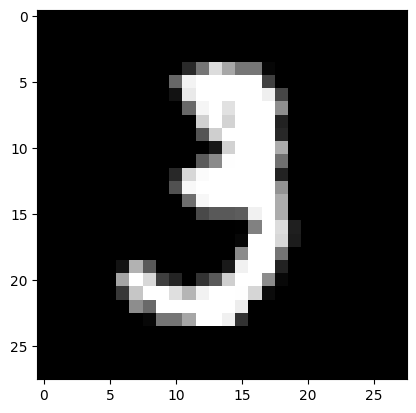

In [102]:
first_img = rotated_imgs.iloc[20,:].values
arr = first_img[:-1]
print(first_img[-1])
img = arr.reshape(28,28).astype(float)
plt.imshow(img,cmap="gray")

In [103]:
def shift_pixels(dataset,min_shift,max_shift,amount_of_shifts):
    new_rows = []
    for i in range(dataset.shape[0]):
        img_cols = dataset.iloc[i,:].values
        img_label = dataset.iloc[i, -1]
        img = img_cols[:-1].reshape(28,28)
        img = img.astype("uint8")
        for c in range(amount_of_shifts):
            random_i = random.randint(int(min_shift), int(max_shift))
            shifted_img = shift(img, shift=[0, random_i])
            img_flat = np.array(shifted_img).flatten()
            img_flat_with_label = np.append(img_flat, img_label)
            new_rows.append(pd.Series(img_flat_with_label, index=dataset.columns))
    augmented_df = pd.DataFrame(new_rows)
    return augmented_df

In [104]:
shifted_imgs = shift_pixels(data_target_merged,1,3,2)
shifted_imgs.shape

(140000, 785)

In [105]:
merged_df = pd.concat([data_target_merged,shifted_imgs,rotated_imgs],axis=0)
merged_df.shape

(350000, 785)

In [106]:
merged_df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [107]:
from sklearn.model_selection import train_test_split

X = merged_df.iloc[:,:-1]
y = merged_df["class"].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [110]:
from sklearn.metrics import confusion_matrix

y_hat = rf.predict(X_test_scaled)
cm = confusion_matrix(y_test,y_hat)
cm

array([[6899,    0,    4,    0,    0,    1,    6,    0,    4,    1],
       [   0, 7857,   18,   15,    5,    0,    8,    8,    4,    5],
       [   9,    2, 6870,   11,    8,    3,    2,   25,   13,    1],
       [   9,    4,   32, 7126,    1,   14,    1,   13,   27,    9],
       [   5,    4,    4,    0, 6644,    0,    8,    3,    6,   36],
       [   7,    2,    2,   37,    5, 6150,   20,    0,    6,   17],
       [  10,    7,    0,    0,    4,   12, 6889,    0,    8,    0],
       [   1,    2,   30,    3,    7,    0,    0, 7222,    3,   40],
       [   4,    8,   16,    9,   20,    6,   11,    2, 6760,   32],
       [  13,    4,    4,   30,   26,   12,    1,   20,   12, 6801]])

In [111]:
from sklearn.metrics import classification_report

class_report = classification_report(y_test, y_hat)

In [112]:
class_report

'              precision    recall  f1-score   support\n\n           0       0.99      1.00      0.99      6915\n           1       1.00      0.99      0.99      7920\n           2       0.98      0.99      0.99      6944\n           3       0.99      0.98      0.99      7236\n           4       0.99      0.99      0.99      6710\n           5       0.99      0.98      0.99      6246\n           6       0.99      0.99      0.99      6930\n           7       0.99      0.99      0.99      7308\n           8       0.99      0.98      0.99      6868\n           9       0.98      0.98      0.98      6923\n\n    accuracy                           0.99     70000\n   macro avg       0.99      0.99      0.99     70000\nweighted avg       0.99      0.99      0.99     70000\n'

In [113]:
merged_df["class"].value_counts()

class
1    39385
7    36465
3    35705
2    34950
9    34790
0    34515
6    34380
8    34125
4    34120
5    31565
Name: count, dtype: int64